# Feature Selection

In [22]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split

input_path = "data.csv"
df = pd.read_csv(input_path, low_memory=False)

# Create grade_composite column

def calculate_grade_composite(row):
    if row.get('gr_none', 0) == 1 or row.get('gr_dk', 0) == 1:
        return np.nan

    grade_values = []
    if row.get('gr_A', 0) == 1:
        grade_values.append(4)
    if row.get('gr_B', 0) == 1:
        grade_values.append(3)
    if row.get('gr_C', 0) == 1:
        grade_values.append(2)
    if row.get('gr_D', 0) == 1:
        grade_values.append(1)
    if row.get('gr_F', 0) == 1:
        grade_values.append(0)

    return np.mean(grade_values) if grade_values else np.nan


df['grade_composite'] = df.apply(calculate_grade_composite, axis=1)

all_prefixes = [
    "grade_composite", "aca_anx", "gad", "anx", "dx_anx", "aca_dep", "phq9", "dep_", "phq2", "dx_dep",
    "aca_eat", "thin_good", "sde", "ed_", "wcs", "body", "weight_", "weigh_", "pfdrug", "scoff",
    "binge", "purge", "diet", "eat", "dx_ea", "aca_add", "dx_neurodev", "disab", "ADHD", "aca_substance",
    "sub", "alc", "drug", "audit", "thc", "nicotine", "pfdrug", "naloxene", "overdose",
    "risk_alc", "risk_cig", "risk_mar", "risk_presc", "risk_vape",
    "care_peer_alc", "est_peer_alc", "est_peer_cig", "est_peer_mar", "est_peer_vape", "est_peer_rxdrug",
    "opioid", "aca_phys_health", "health", "dx_chronic", "exerc", "TBI", "eatprac", "diet_veg",
    "sex_partner", "birthcontrol", "nobc", "STI", "preg",
    "aca_phys_assault", "abuse", "stalk", "IPV", "HITS",
    "aca_sex_assault", "sa_", "revoke"
]

filtered_columns = [col for col in df.columns if any(col.startswith(prefix) for prefix in all_prefixes)]
df_filtered_all = df[filtered_columns]

missing_ratio = df_filtered_all.isna().mean()
df_filtered = df_filtered_all.loc[:, missing_ratio < 0.95]

X = df_filtered.drop('grade_composite', axis=1)
y = df_filtered['grade_composite']
valid_mask = ~y.isna()
X = X[valid_mask].copy()
y = y[valid_mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

missing_ratio_train = X_train.isna().mean()
cols_with_missing = missing_ratio_train[missing_ratio_train > 0.2].index
for col in cols_with_missing:
    X_train[col + "_missing"] = X_train[col].isna().astype(int)
    X_test[col + "_missing"] = X_test[col].isna().astype(int)

selector = VarianceThreshold(threshold=0.01)
X_train_sel = selector.fit_transform(X_train)
X_test_sel = selector.transform(X_test)
selected_cols = X_train.columns[selector.get_support()]

X_train_sel = pd.DataFrame(X_train_sel, columns=selected_cols, index=X_train.index)
X_test_sel = pd.DataFrame(X_test_sel, columns=selected_cols, index=X_test.index)

print(f"Selected {X_train_sel.shape[1]} features after variance thresholding")
print(f"Train samples: {X_train_sel.shape[0]}  Test samples: {X_test_sel.shape[0]}")

C:\Users\School\AppData\Local\Temp\ipykernel_4152\2632433466.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['grade_composite'] = df.apply(calculate_grade_composite, axis=1)


Selected 165 features after variance thresholding
Train samples: 60848  Test samples: 15213


# Baseline Model

HistGradientBoostingRegressor Train R^2: 0.1717
HistGradientBoostingRegressor Test R^2: 0.0880


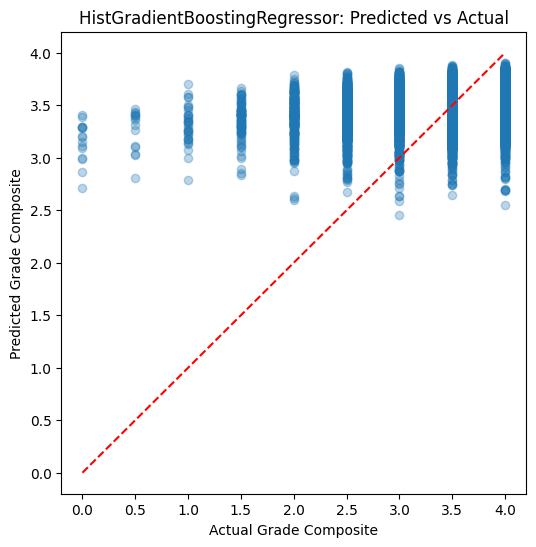

Top 20 HistGradientBoostingRegressor features:
                Feature  Importance
                 phq9_6    0.028041
               dep_impa    0.015253
                 gad7_4    0.012349
  dep_tx_know_1_missing    0.011251
                 gad7_1    0.005953
                 phq9_1    0.005570
             dep_secret    0.005151
anx_help_know_1_missing    0.003755
  dep_tx_know_2_missing    0.003077
                 phq9_8    0.002881


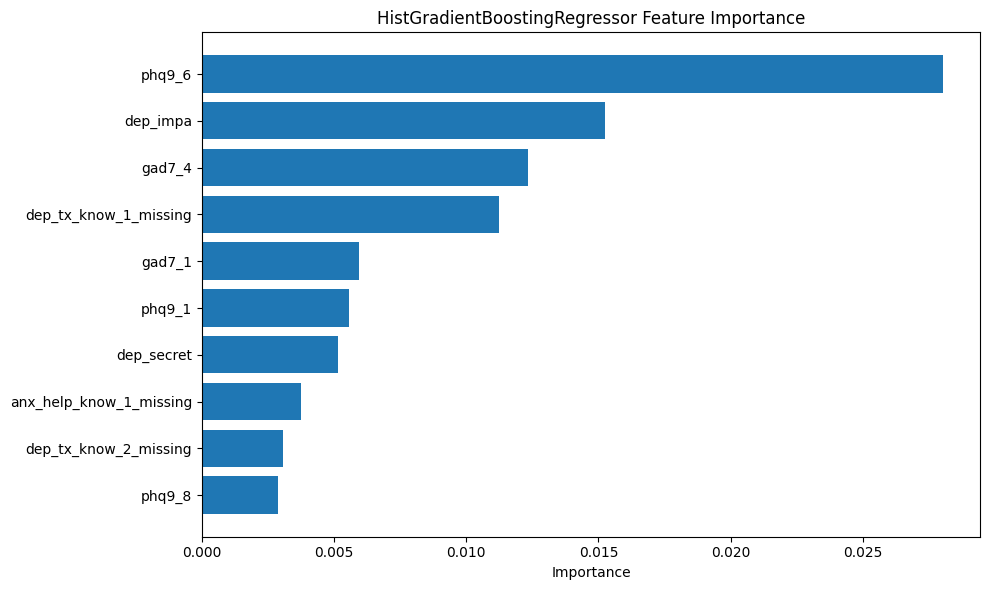

In [23]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

baseline = HistGradientBoostingRegressor(random_state=42)
baseline.fit(X_train_sel, y_train)

r2_train = baseline.score(X_train_sel, y_train)
r2_test = baseline.score(X_test_sel, y_test)
print(f"HistGradientBoostingRegressor Train R^2: {r2_train:.4f}")
print(f"HistGradientBoostingRegressor Test R^2: {r2_test:.4f}")

# Predicted vs actual

y_pred = baseline.predict(X_test_sel)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel("Actual Grade Composite")
plt.ylabel("Predicted Grade Composite")
plt.title("HistGradientBoostingRegressor: Predicted vs Actual")
plt.show()

# Permutation importance for HistGradientBoosting
perm_importance = permutation_importance(
    baseline,
    X_test_sel,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
importance_df_hist = pd.DataFrame({
    'Feature': X_train_sel.columns,
    'Importance': perm_importance.importances_mean
}).sort_values('Importance', ascending=False)

top_n = 10
print("Top 20 HistGradientBoostingRegressor features:")
print(importance_df_hist.head(top_n).to_string(index=False))

importance_df_hist_plot = importance_df_hist.head(top_n)
plt.figure(figsize=(10,6))
plt.barh(importance_df_hist_plot['Feature'][::-1], importance_df_hist_plot['Importance'][::-1])
plt.xlabel('Importance')
plt.title('HistGradientBoostingRegressor Feature Importance')
plt.tight_layout()
plt.show()

# New Model

Ensemble Train R^2: 0.2166
Ensemble Test R^2: 0.0934


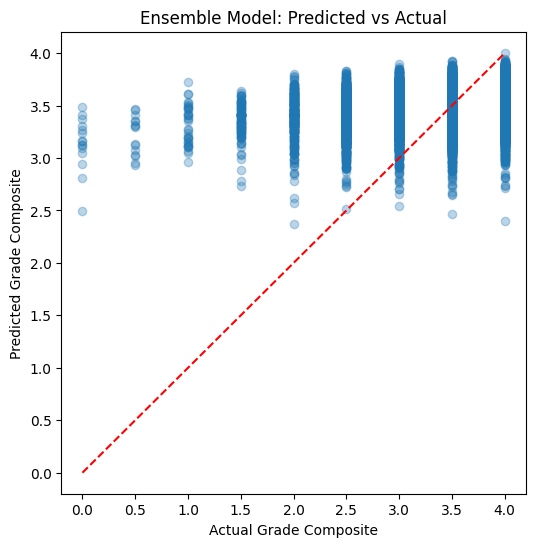

Top 20 ensemble features:
              Feature  CatBoost_Importance  LightGBM_Importance  Average_Importance
             dep_impa             0.045353             0.031667            0.038510
               phq9_6             0.043948             0.024333            0.034141
               gad7_4             0.027059             0.032333            0.029696
            anx_score             0.022043             0.026333            0.024188
              disab_2             0.016349             0.025333            0.020841
dep_tx_know_1_missing             0.024085             0.015667            0.019876
                exerc             0.013438             0.025333            0.019386
           dep_secret             0.012010             0.026333            0.019172
               phq9_8             0.020956             0.017333            0.019145
               phq2_2             0.017020             0.021000            0.019010


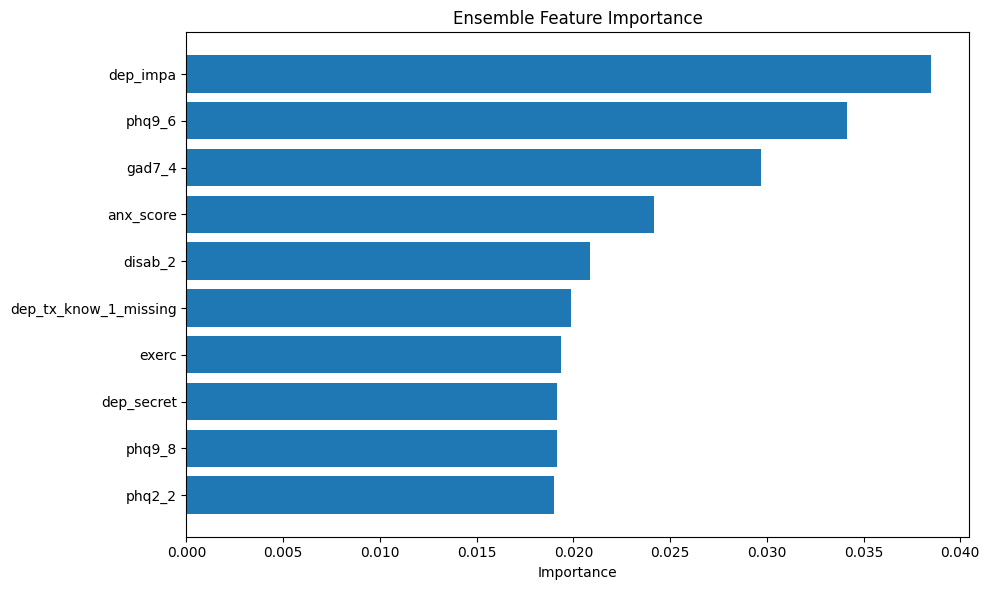

In [24]:
from sklearn.ensemble import VotingRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

ensemble = VotingRegressor([
    ('catboost', CatBoostRegressor(random_state=42, verbose=0)),
    ('lgbm', LGBMRegressor(random_state=42, verbose=-1))
])
ensemble.fit(X_train_sel, y_train)

r2_train = ensemble.score(X_train_sel, y_train)
r2_test = ensemble.score(X_test_sel, y_test)
print(f"Ensemble Train R^2: {r2_train:.4f}")
print(f"Ensemble Test R^2: {r2_test:.4f}")

# Predicted vs actual

y_pred = ensemble.predict(X_test_sel)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel("Actual Grade Composite")
plt.ylabel("Predicted Grade Composite")
plt.title("Ensemble Model: Predicted vs Actual")
plt.show()

# Ensemble feature importance
cat_model = ensemble.named_estimators_['catboost']
lgbm_model = ensemble.named_estimators_['lgbm']
catboost_importance = cat_model.get_feature_importance()
lgbm_importance = lgbm_model.feature_importances_

catboost_norm = catboost_importance / np.sum(catboost_importance)
if np.sum(lgbm_importance) == 0:
    lgbm_norm = np.zeros_like(lgbm_importance)
else:
    lgbm_norm = lgbm_importance / np.sum(lgbm_importance)

importance_df_ensemble = pd.DataFrame({
    'Feature': X_train_sel.columns,
    'CatBoost_Importance': catboost_norm,
    'LightGBM_Importance': lgbm_norm,
    'Average_Importance': (catboost_norm + lgbm_norm) / 2
}).sort_values('Average_Importance', ascending=False)

top_n = 10
print("Top 20 ensemble features:")
print(importance_df_ensemble.head(top_n).to_string(index=False))

importance_df_ensemble_plot = importance_df_ensemble.head(top_n)
plt.figure(figsize=(10,6))
plt.barh(importance_df_ensemble_plot['Feature'][::-1], importance_df_ensemble_plot['Average_Importance'][::-1])
plt.xlabel('Importance')
plt.title('Ensemble Feature Importance')
plt.tight_layout()
plt.show()